In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm


In [3]:
result_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0415_1053_loth_baker_corrs_30_100")

In [4]:
sc_results = pd.read_parquet(result_dir / "val_scenario_results.parquet")

In [7]:
event = "3528839"
site_int = "CBGS"

cur_sc_results = sc_results[(sc_results["event_id"] == event) & (sc_results["site_int"] == site_int)]

Looks at how the loss changes when the number of realisations with P(R_i) > 0 is increased, with the uniform probabilities across the non-zero realisations

In [8]:
cur_im = "pSA_2.0"
cur_df = cur_sc_results[["rel_id", f"{cur_im}_prob", f"{cur_im}_misfit", f"{cur_im}_residual"]]

In [16]:
# Uniform probabilities
prob = np.ones(100) / 100
loss = np.sum(prob * cur_df[f"{cur_im}_misfit"].values)
print("Uniform loss: ", loss)

Uniform loss:  3.7029100693762302


In [18]:
# Lowest loss
min_loss = np.min(cur_df[f"{cur_im}_misfit"].values)
print(f"Lowest loss: {min_loss}")

Lowest loss: 0.2085392326116562


In [19]:
# Model loss
prob = cur_df[f"{cur_im}_prob"].values
loss = np.sum(prob * cur_df[f"{cur_im}_misfit"].values)
print(f"Model loss: {loss}")

Model loss: 1.4381811618804932


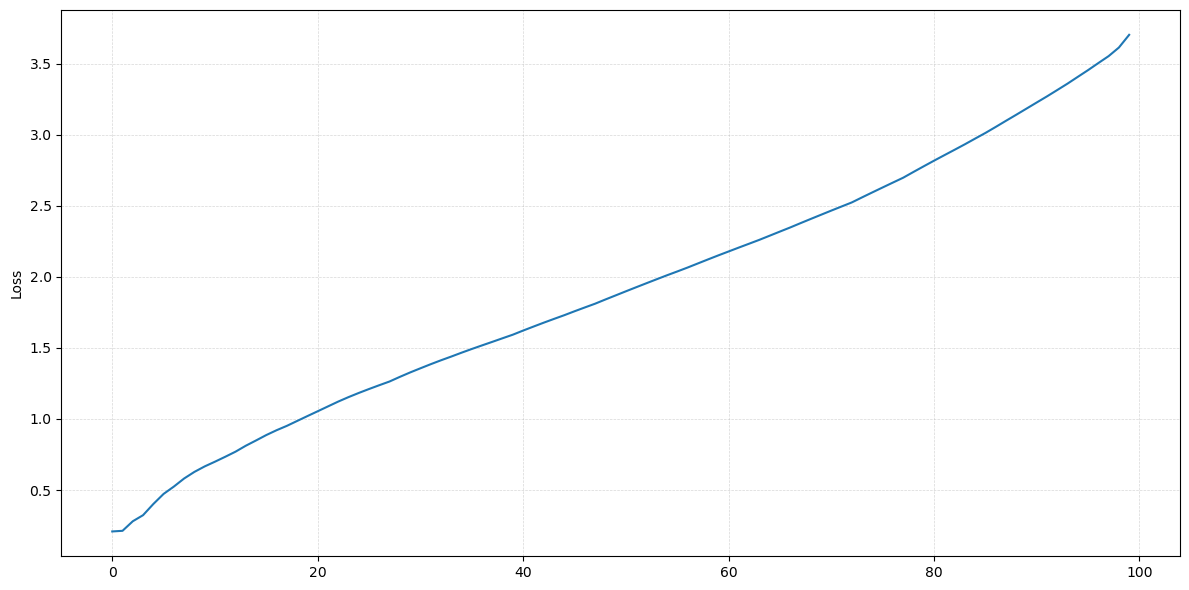

In [21]:
misfit_results = []

for i in range(1, 101):
	cur_prob = np.zeros(100)
	cur_prob[:i] = 1 / i
	cur_misfit = np.sort(cur_df[f"{cur_im}_misfit"].values)
	
	cur_loss = np.sum(cur_prob * cur_misfit)
	misfit_results.append(cur_loss)
	
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(misfit_results)
ax.set_ylabel(f"Loss")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()


## Loss Penalty for sparse realisation solutions
- Look at how adding penalty term to the loss function could be used to reduce sparsity in the realisation "selection"
- Only looking at L2 since L1 is always 1.0 as the probabilities have to sum to 1

In [100]:
def gen_probs(std: float):
	lower, upper = 0, 1
	mean = 0.5
	rand_values = truncnorm.rvs((lower - mean) / std, (upper - mean) / std, loc=mean, scale=std, size=10000)
	
	# rand_values = np.random.normal(5.0, 10.0, 1000)
	c, _ = np.histogram(rand_values, bins=100, range=(0, 1))
	probs = c.astype(float) / c.sum()
	
	return probs
	

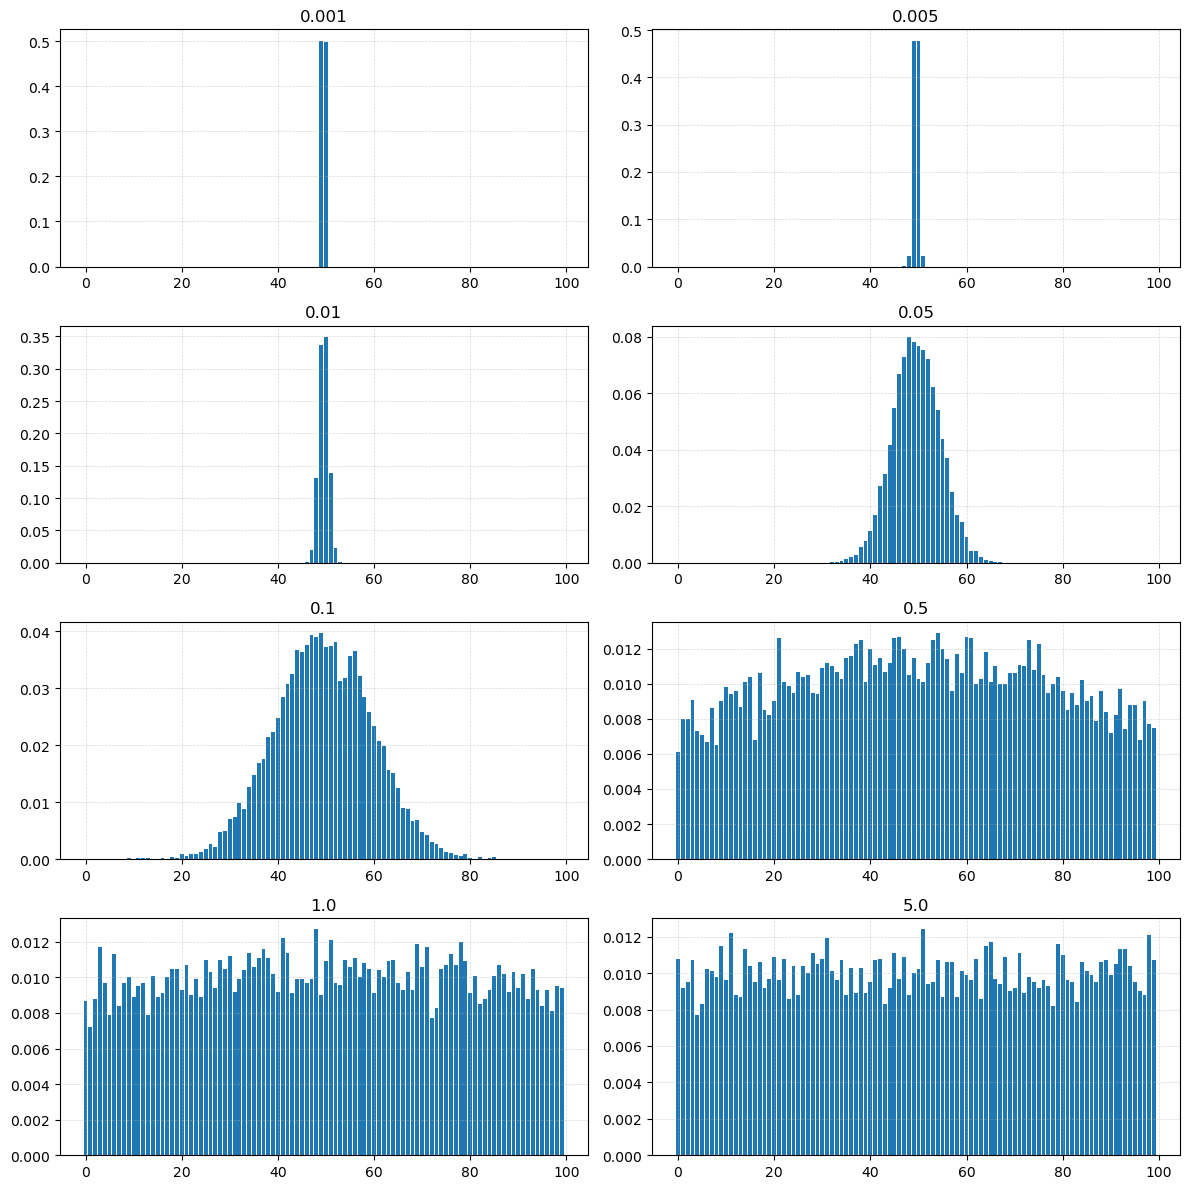

In [108]:
# std_values = np.linspace(0.01, 0.1, 10)
std_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]
probs = [gen_probs(cur_std) for cur_std in std_values]
l1_values = [np.sum(prob) for prob in probs]
l2_values = [np.sum(prob ** 2) for prob in probs]

fig, axs = plt.subplots(4, 2, figsize=(12, 12))
axs = axs.flatten()

for ix, (cur_probs, cur_ax) in enumerate(zip(probs, axs)):
	cur_ax.bar(np.arange(100), cur_probs)
	
	cur_ax.set_title(f"{std_values[ix]}")
	cur_ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
fig.tight_layout()

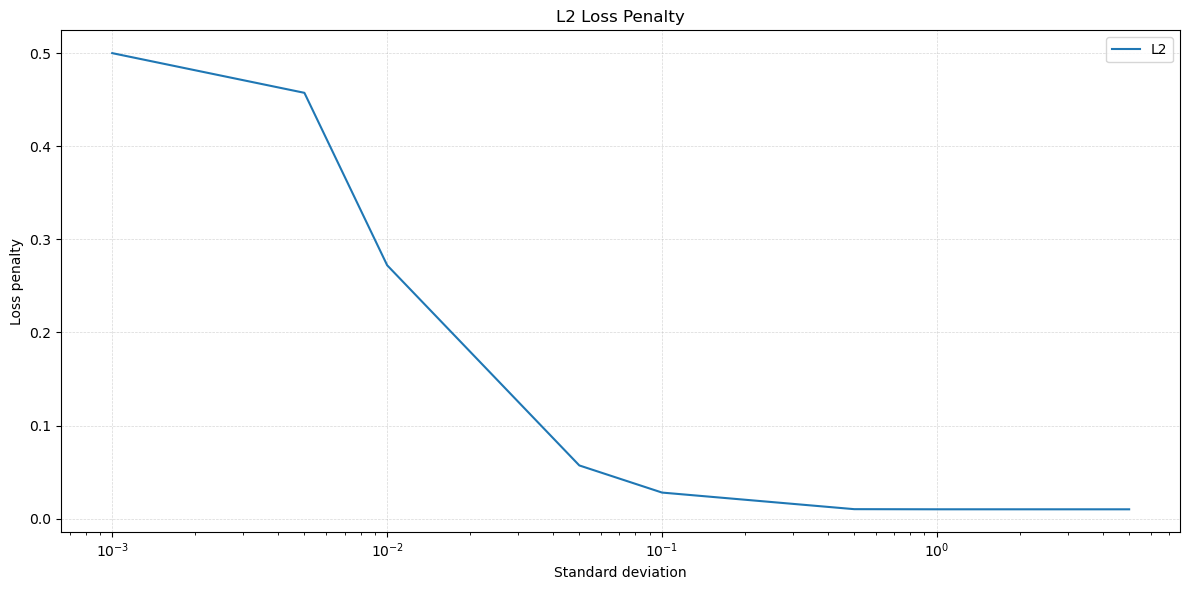

In [111]:
fig, ax = plt.subplots(figsize=(12, 6))

# ax.plot(std_values, l1_values, label="L1")
ax.semilogx(std_values, l2_values, label="L2")
# ax.axhline(uniform_l1, color="black", linestyle="--", label="Uniform L1")
# ax.axhline(uniform_l2, color="black", linestyle="--", label="Uniform L2")

ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax.set_xlabel("Standard deviation")
ax.set_ylabel("Loss penalty")
ax.set_title("L2 Loss Penalty")
ax.legend()

fig.tight_layout()

This seems like a viable option